# Title: Customer Churn Prediction and Retention Analysis

## Problem Statement:
- Customer churn is the number of existing customers lost, for any reason at all, over a given period of time. It provides companies with an understanding of customer satisfaction and customer loyalty, and can identify potential changes in a company’s bottom line.[1]

- Churn affects B2B and B2C differently:
    - B2C customers do not need to get approval from a boss to start or finish a subscription, so they are more likely to impulse buy and impulse quit. Second, subscriptions are also likely to be cheaper, which means it’s easier to leave one service and start another. [1]
    - B2B companies either sell products or services. The former is often a one-time fee for an individual product. For those who sell software-as-a-service solutions, that is, SaaS companies, they can charge customers multiple times during the year for access to the service. The latter depends on their customers (subscribers) paying a monthly recurring revenue. [1]

## Calculating Churn Rate
- Churn Rate:
      Churn rate = (Lost customers/Total customers at the start of time period) x 100 [1]
- Monthly Recurring Revenue (MRR):
      MRR = Number of subscribers x average revenue per subscriber (ARPU) [1]
- Revenue Churn Rate:
      Revenue churn rate = (Revenue lost to churn/Total MRR in the time period) x 100 [1]


## Reference:
[1] : [IBM Customer Churn](https://www.ibm.com/think/topics/customer-churn)
[2] : [IBM Teleco Customer Churn](https://community.ibm.com/community/user/blogs/steven-macko/2019/07/11/telco-customer-churn-1113)


# Day-1
## Project Objective
The primary objective of this project is to analyze customer behavior patterns and predict whether a customer is likely to churn using machine learning techniques.

By identifying high-risk customers early, businesses can:

improve customer retention strategies,
reduce revenue loss,
increase customer lifetime value,
and make data-driven business decisions.

This project focuses on:

exploratory data analysis (EDA),
customer behavior analysis,
feature engineering,
churn prediction using classification models,
and business insights for customer retention.

## Business Problem
Customer acquisition is often more expensive than customer retention. Telecom companies face significant financial losses when customers discontinue their services.

The challenge is to identify customers who are likely to churn before they leave the service.

Using predictive analytics and machine learning, companies can:

proactively target at-risk customers,
optimize retention campaigns,
improve customer satisfaction,
and reduce churn-related revenue loss.

## Machine Learning Task
This project is a supervised machine learning classification problem where:

Input: Customer demographic, account, and service-related features
Output: Whether the customer churns or not

Target Variable:

Churn
Yes → Customer left the company
No → Customer stayed with the company

In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Success: Libraries imported")

Success: Libraries imported


In [19]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
# Last 5 values
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [21]:
# Dataset Shape
df.shape

(7043, 21)

In [22]:
# Columns
print("Columns in dataset")
for column_name in df.columns:
    print(column_name)

Columns in dataset
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [23]:
# Information of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [24]:
# Numeric columns (statistical summary)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [25]:
# Missing Values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [26]:
# Duplicate Rows
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  0


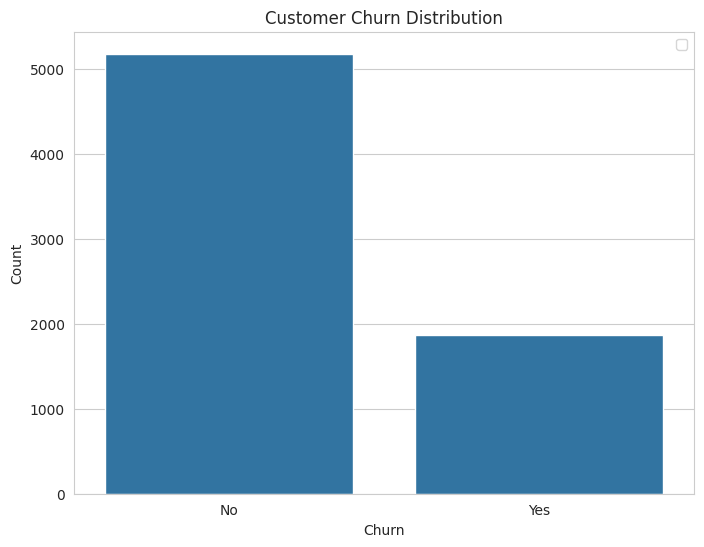

In [27]:
# Target Distribution: Churn
# Plot: Churn vs Count graph
plt.figure(figsize=(8,6))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.legend()
plt.show()

## Important Obeservation:
- Dataset looks rather clean with neither missing values nor duplicate values
- There is imbalance in dataset: more No churn then Yes
- Appropriate evaluation metrics and possibly resampling or class-weighted models
- Recall on churn class is important 

In [28]:
# Churn Percentage
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [29]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical Features: ", numerical_features)
print("Categorical Features: ", categorical_features)

Numerical Features:  ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical Features:  ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


## Customer Demographics

### Gender vs Churn

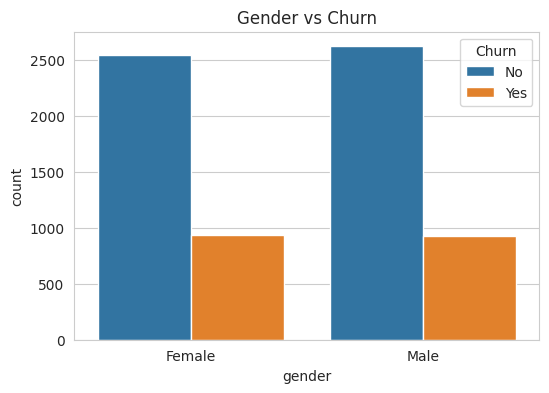

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.show()

- Churn distribution appears similar across genders
- Gender alone may not be a strong predictor of churn (but it may interactwith other features)

### Senior Citizen vs Churn

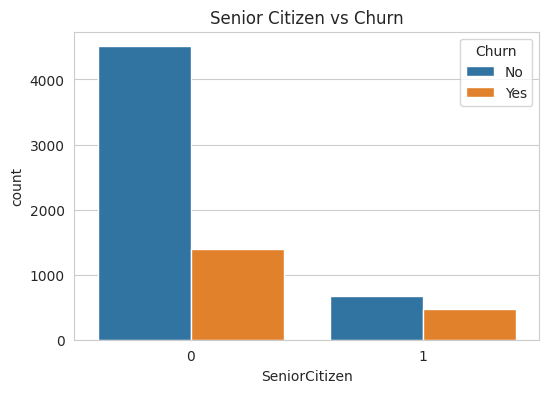

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Senior Citizen vs Churn')
plt.show()

- Not senior citizen: 0, Yes senior citizen: 1
- Senior citizens appera to have a higher proportion of churn compared to non-senior customers
- Reason: Product fit, Pricing Sensitivity, or Service usability

### Contract Type vs Churn

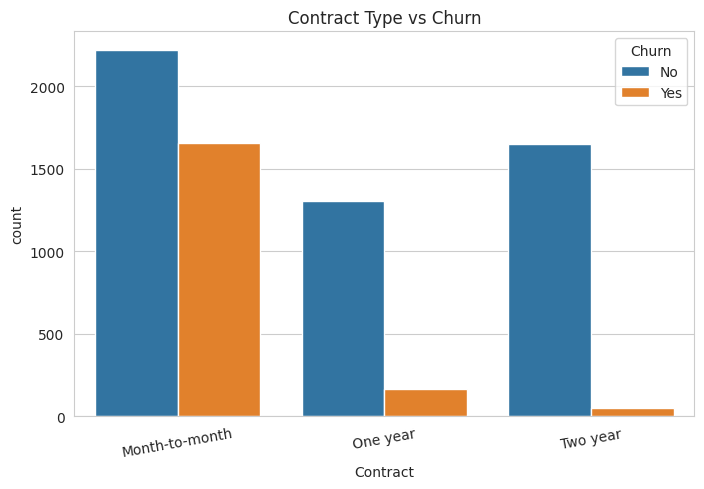

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=10)
plt.show()

- Count: Month-to-Month > Two-Year > One-Year
- Customers with Month-to-Month contracts have significantly higher churn rate
- Longer Contracts (in terms of year) show lower churn (suggests contract length increases retention)

### Payment Method vs Churn

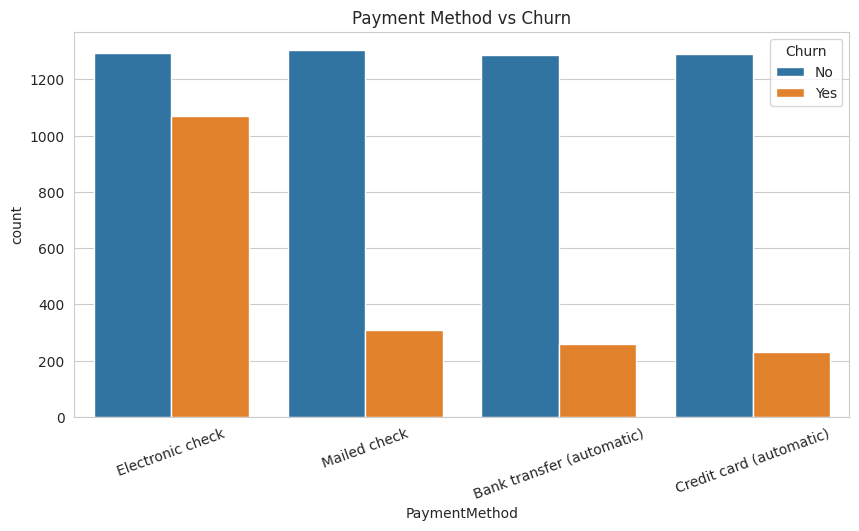

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=20)
plt.show()

- Electronic checks show higher churn proportions
- Possible indications: failed payments, billing friction or differences in customer segments

### Tenure Distribution

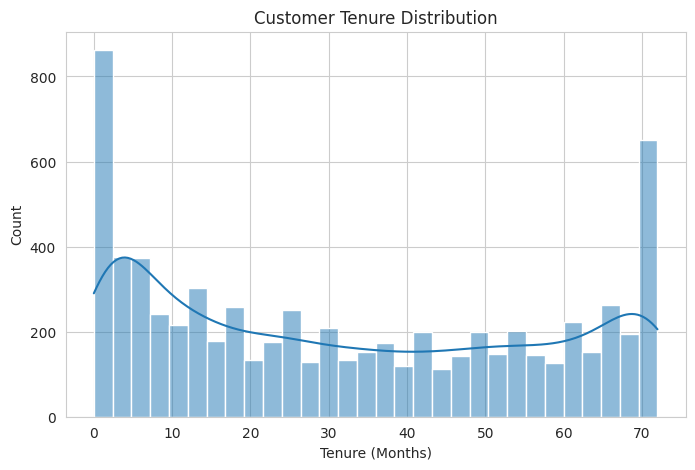

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.show()

- Tenure distribution is skewed toward newer customers (shorter tenure).
- short-tenure customers are more likely to churn